# 🎬 Netflix Content Analysis

## 📌 Project Overview

Netflix is one of the world's leading streaming platforms, offering thousands of movies and TV shows across different countries, genres, and audience categories. Understanding the characteristics of its content library can help identify trends in content production, regional preferences, and opportunities for future investments.

This project performs Exploratory Data Analysis (EDA) on the Netflix Titles dataset to uncover meaningful insights about content type, release patterns, genres, countries, ratings, and duration.

---

## 🎯 Business Problem

Netflix wants to understand how its content library has evolved over time and identify patterns that can guide future content acquisition and production strategies.

---

## 🎯 Project Objectives

- Analyze the distribution of Movies and TV Shows.
- Identify trends in content releases over time.
- Explore the most common genres and producing countries.
- Study audience ratings and content duration.
- Generate business insights and strategic recommendations based on the analysis.

---

## 🛠️ Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

**Downloading the data:**

**Import Libraries:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Reading the data:**

In [ ]:
data=pd.read_csv("netflix.csv")

In [ ]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Data Understanding

In [ ]:
data.shape

(8807, 12)

**1.1.We have 8807 rows and 12 Columns in the data.**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**1.2 We have 10 of the columns of "object" data type and 1 column of "integer" data type.**

In [ ]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**1.3.It is observed that we have movies/shows released during 1925 to 2021 present in the Netflix data.**

**1.4.Rough statistical info about "object data type" columns of the data:**

In [ ]:
data.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


**1.5. Null values check:**

In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Comments:**

There are 2634 missing or null values in "director" column, 825 in "cast" column, 831 in "country" column , 10 in "date_added" column,4 in "rating"
column and "3" in duration column, rest all 5 columns have no null values.

Thus there are more null values in columns -- director, cast and country.

**1.6.Missing values check:**


In [ ]:
data.select_dtypes(include="object").apply(lambda x:x.str.strip().eq("").sum())

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
rating,0
duration,0
listed_in,0


**Comments:**
We have no empty rows in any of the columns in the data.

## 2. Data Cleaning & Preprocessing

**2.1.Coverting "date_added" column from "object type" to "date_time type" and extracting "year" and "month" columns for better processing:**

In [ ]:
data["date_added"]=data["date_added"].str.strip()
data["date_added"]=pd.to_datetime(data["date_added"],errors="coerce")
data["year_added"]= data["date_added"].dt.year
data["month_added"]=data["date_added"].dt.month

In [ ]:
data[["year_added","date_added","month_added"]].head()

,year_added,date_added,month_added
0,2021.0,2021-09-25,9.0
1,2021.0,2021-09-24,9.0
2,2021.0,2021-09-24,9.0
3,2021.0,2021-09-24,9.0
4,2021.0,2021-09-24,9.0


**2.2. Replacing null values in "object" data type columns with "Unknown":**

In [ ]:
for col in data.select_dtypes(include="object").columns:
  data[col]=data[col].fillna("Unknown")

**Comments:**

All object data type of columns now have "null values" replaced by "Unknown",except null values of the "int type" column -- "date_added".

**2.3."Unnesting":**

Unnesting of columns "director", "cast","country" ,"listed_in" is done upon data by creating a seperate copy of the Netflix data frame for each Column's unnesting, while the original dataframe "data" remains safe too.

**2.3.1. "cast" column is unnested and "data__cast" data frame is created for that data:**

In [ ]:
data__cast=data.copy()
data__cast["cast"]=data__cast["cast"].str.split(",")
data__cast=data__cast.explode("cast",ignore_index=True)
data__cast["cast"]=data__cast["cast"].str.strip()
data__cast.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s2,TV Show,Blood & Water,Unknown,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
3,s2,TV Show,Blood & Water,Unknown,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
4,s2,TV Show,Blood & Water,Unknown,Thabang Molaba,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0


In [ ]:
data__cast.shape

(64951, 14)

**2.3.2. "country" column is unnested and "data__country" data frame is created for that data:**

In [ ]:
data_country=data.copy()
data_country["country"]=data_country["country"].str.split(",")
data_country=data_country.explode("country",ignore_index=True)
data_country["country"]=data_country["country"].str.strip()
data_country.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [ ]:
data_country.shape

(10850, 14)

**2.3.3. "director" column is unnested and "data__director" data frame is created for that data:**

In [ ]:
data__director=data.copy()
data__director["director"]=data__director["director"].str.split(",")
data__director=data__director.explode("director",ignore_index=True)
data__director["director"]=data__director["director"].str.strip()
data__director.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [ ]:
data__director.shape

(9612, 14)

**2.3.4. "listed_in" column is unnested and "data__listed_in" data frame is created for that data.**

In [ ]:
data_listed_in=data.copy()
data_listed_in["listed_in"]=data_listed_in["listed_in"].str.split(",")
data_listed_in=data_listed_in.explode("listed_in",ignore_index=True)
data_listed_in["listed_in"]=data_listed_in["listed_in"].str.strip()
data_listed_in.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
3,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021.0,9.0
4,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021.0,9.0


In [ ]:
data_listed_in.shape

(19323, 14)

In [ ]:
data.shape

(8807, 14)

**Comments:**

Thus we can observe that copy of each of unnested dataframe is created for each nested column,thus the number of rows have increased for each of such dataframes as we used split and explode.

**2.4.Converting Category attributes to"category data type":**

In [ ]:
cat_cols=["type","rating"]
for col in cat_cols:
  data[col]=data[col].astype("category")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   category      
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   category      
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8797 non-null   float64       
 13  month_added   8797 non-null   float64       
dtypes: category(2), datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 843.8+ 

## 3. Non-Graphical Analysis

In [ ]:
data["title"].nunique()

8807

**3.1.There are 8807 total movies & shows combined.**

In [ ]:
data["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


**3.2.There are 6131 movies and 2676 Tv shows listed in the data.**

In [ ]:
data["director"].nunique()

4529

In [ ]:
data__director["director"].nunique()

4994

**3.3.There were more than one directors listed under few movies/Tv shows and thus we can see that unique individual directors listed in the data are "4994" after unnesting.**

In [ ]:
data["cast"].nunique()

7693

In [ ]:
data__cast["cast"].nunique()

36440

**3.4."cast" column also contained multiple values initially for each title, but after applying "split and explode", we see that there are 36440 unique actors involved in this data.**

In [ ]:
data["country"].nunique()

749

In [ ]:
data_country["country"].nunique()

124

In [ ]:
data_country["country"].value_counts().head()

,count
country,
United States,3690
India,1046
Unknown,831
United Kingdom,806
Canada,445


**3.5.After unnesting countries listed under each title,we have total of 124 unique countries and United states is the highest producer of movies/shows followed by India ,UK and Japan.**

In [ ]:
data["year_added"].agg(["min","max"])

,year_added
min,2008.0
max,2021.0


In [ ]:
data["year_added"].value_counts()

,count
year_added,
2019.0,2016
2020.0,1879
2018.0,1649
2021.0,1498
2017.0,1188
2016.0,429
2015.0,82
2014.0,24
2011.0,13


**3.6. Though Netflix started adding movies/shows in 2008 and we have the data upto year 2021, We can see that highest movies/shows were added in year 2019 of 2016 in number, followed by 1879 in 2020, 1649 in 2018 etc., and the minimum of 1 added in 2010 followed by 2 in 2008 & 2009.**

In [ ]:
data["release_year"].agg(["min","max"])

,release_year
min,1925
max,2021


In [ ]:
data["release_year"].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


**3.7. Though we have movies/shows released during 1925 upto 2021, We can see that maximum movies/shows listed in Netfix were those which were released in year "2018" followed by 2017 U& 2019 and the least were of years 1947,1966etc.**

In [ ]:
data["listed_in"].nunique()

514

In [ ]:
data_listed_in["listed_in"].nunique()

42

In [ ]:
data_listed_in["listed_in"].value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


**3.8. It is observed that there are highest number of movies/shows under the "International movies" followed by "Dramas" and "Comedies", this clear to us after unnesting listed_in column.**

In [ ]:
data["rating"].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**3.9. These are the different types of ratings or restrictions given to each of the movies/tv shows which restrict or inform which age groups can watch them
and it is evident that maximum number of movies and tv shows are for adults or matured audiences or which need parent supervision.**

## 4. Visual Analysis

**4.1. Univariate Analysis -- 4.1.1. Type distribution(Categorical):**

<Figure size 600x400 with 0 Axes>

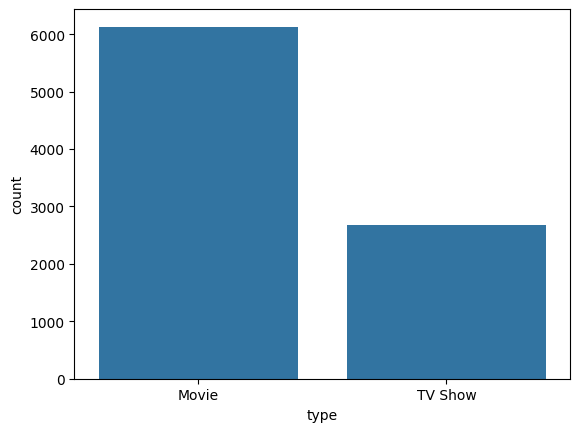

<Figure size 600x400 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=data)

### Interpretation:

From visual analysis it is evident that there are around 6000 movies amd around 2000 tvshows added to Netflix,making Movies the dominating list_type.

Netflix library is movie-heavy.

**Recommendation:**

Though movies dominate supply, Tv shows drive long-term engagement,thus i would recommend to increase production of Tv series to improve user retention.


**4.1.2. Release year distribution(Num/Continuous):**

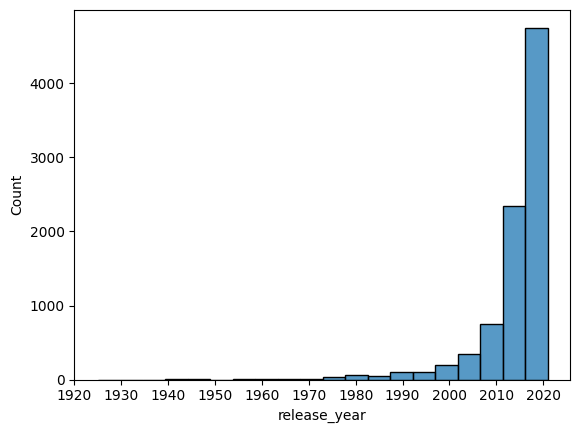

In [ ]:
sns.histplot(x="release_year",data=data,bins=20)
plt.xticks(range(1920,2021,10))
plt.show()


### Interpretation:

We can see that maximum number of movies/tvshows added to Netflix were the ones released after 2015 and ones produced before are lesser and very few in comparision to prior years they were released.**

Netflix is dominated by recent content,especially post 2015.**

**Recommendations:**

Netflix can continue investing in new releases,but must consider adding classic films to attract older demographics.

**4.1.3. Ratings Distribution(Categorical):**

<Axes: xlabel='rating', ylabel='count'>

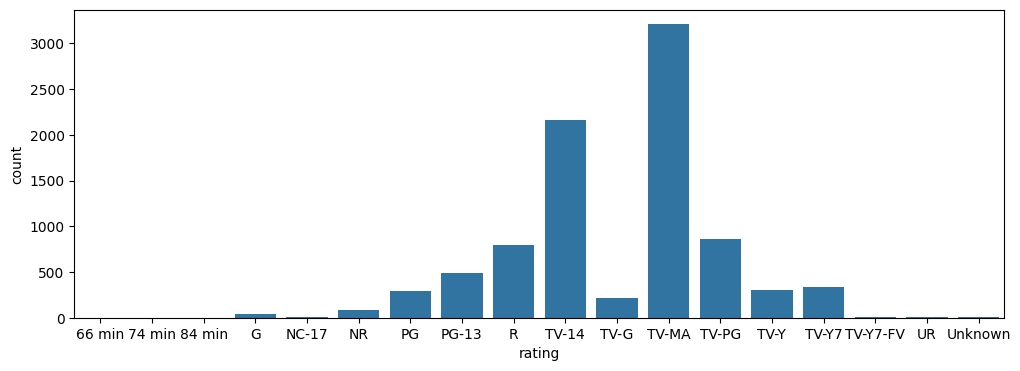

In [ ]:
plt.figure(figsize=(12,4))
sns.countplot(data=data,x="rating")


### Interpretation:

We can see that movies/shows with rating/restrictions  "TV-MA" are the highest followed by "TV-14" and "TV-PG & R".

Most content targets mature audiences.**

**Recommendations:**

Netflix can expand PG and family-friendly content and diversify audience targetting.

**4.1.4.A. Cleaned Duration-data of Movies only(Num/Continuous):**

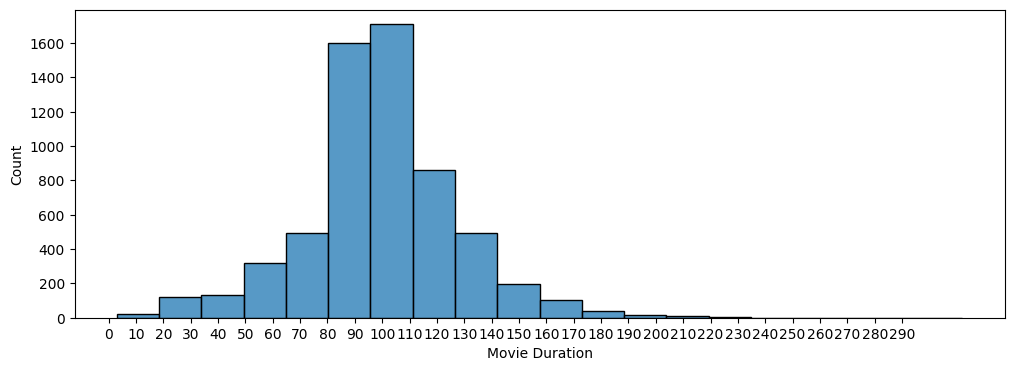

In [ ]:
duration_cleaned= data["duration"].str.strip().str.split(" ")
datanew=data.copy()
datanew["durationnew"]=duration_cleaned.str[0]
datanew["durationnew"]=pd.to_numeric(datanew["durationnew"],errors="coerce")
datanew.head()
data_movies=datanew[datanew["type"]=="Movie"]
data_tvshows=datanew[datanew["type"]=="TV Show"]

plt.figure(figsize=(12,4))
sns.histplot(data_movies['durationnew'],bins=20)
plt.xlabel("Movie Duration")
plt.xticks(range(0,300,10))
plt.show()

### Interpretation:

### Interpretation

- Most Netflix movies have a duration between 80 and 120 minutes.
- Very short and very long movies are comparatively less common.
- Netflix appears to focus primarily on feature-length films.

**Recommendations:**

It is good to focus on 80-120 minutes films for higher engagement and avoid excessive long-duration movies unless premium content.

**4.1.4.B. Cleaned Duration-data of Tv-Shows only(Num/Continuous):**

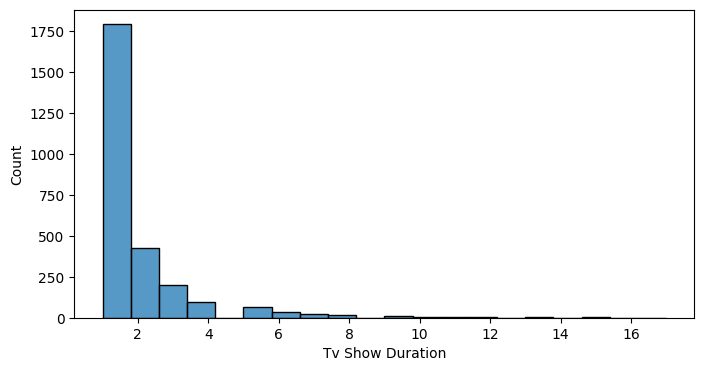

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data_tvshows['durationnew'],bins=20)
plt.xlabel("Tv Show Duration")
plt.show()

### Interpretation:

It is evident that Tv-Shows with 1 season are the most highest,followed by 2 and 3 seasons.

Netflix tends to host shorter series than long-running shows.

**Recommendations:**

Continue producing short-running series,but can invest in long-running series with upto 4 seasons.

**4.2. Exploded Data--Visual Analysis -- 4.2.1. Top 10 Genres:**

<Axes: xlabel='listed_in', ylabel='count'>

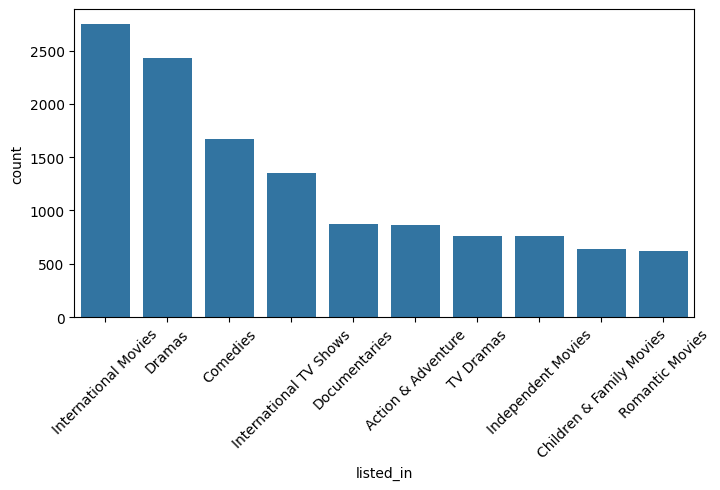

In [ ]:
plt.figure(figsize=(8,4))
plt.xticks(rotation=45)
sns.countplot(x="listed_in",data=data_listed_in,order=data_listed_in["listed_in"].value_counts().head(10).index)

### Interpretation:
From the plot it is clear that maximum movies fall under genre "International movies" followed by "Dramas" and "Comedies".

International movies and Drama are major pillars of Netflix.

**Recommendations:**

 Continue strong investment in Drama and expand localized international content.

**4.2.2. Top 10 Countries (Exploded):**

<Axes: xlabel='country', ylabel='count'>

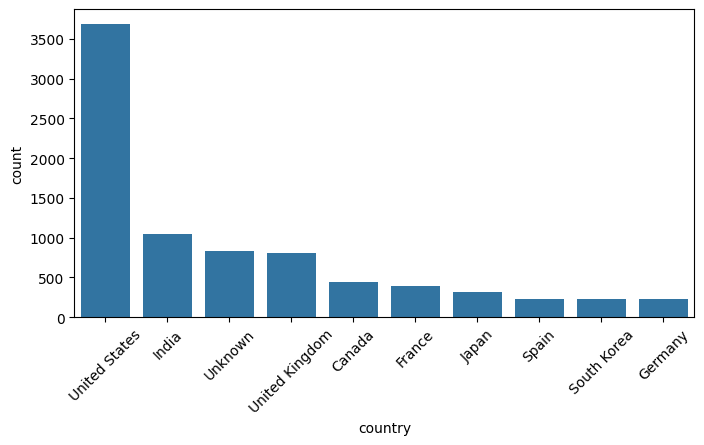

In [ ]:
plt.figure(figsize=(8,4))
plt.xticks(rotation=45)
sns.countplot(
    x="country",
    data=data_country,
    order=data_country["country"].value_counts().head(10).index
)

### Interpretation:

It is observed that "United states" is the top producer of movies listen in Netflix followed by "India" and "United Kingdom".


USA dominates content production in Netflix.

**Recommendations:**

 Netflix should invest more in Countries like India and UK whic can turn into high growth markets.

**4.3. BIVARIATE ANALYSIS(Relationship between TWO variables) -- 4.3.1. Rating vs Type(Count plot):**

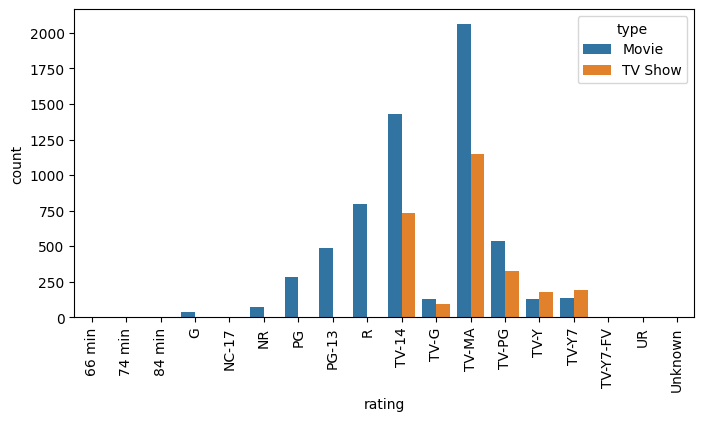

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x="rating", hue="type", data=data)
plt.xticks(rotation=90)
plt.show()

### Interpretation:   
It is observed that maximum Tv shows and Movies fall under Tv-MA and TV-14
ratings.

Both movies and Tv shows are targetting mature audience mainly.


**Recommendations:**

  Other rated movies and Tv show also must be balanced to attract all ages and family audiences.

**4.3.2. Country vs Type--Count plot (Exploded):**

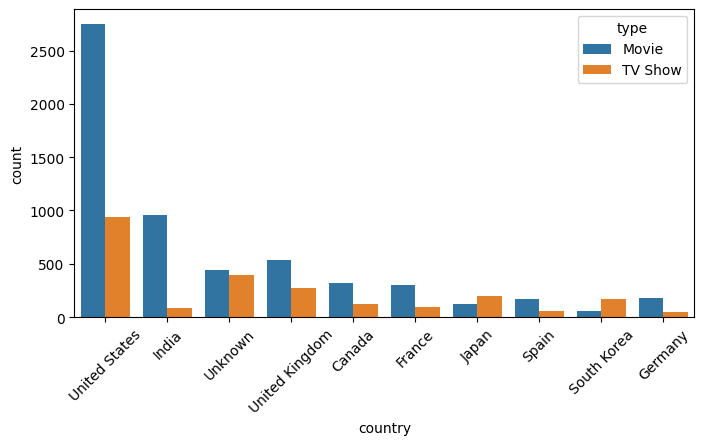

In [ ]:
plt.figure(figsize=(8,4))
plt.xticks(rotation=45)
sns.countplot(
    x="country",
    hue="type",
    data=data_country,
    order=data_country["country"].value_counts().head(10).index
)
plt.show()

### Interpretation: Compared to other top 10 Countries, India has very few Tv shows compared to movies produced.

**Recommendations:**  It can be profitable to invest in producing Tv shows also in Top 2nd contributing Country like India.

**4.3.3. Release Year vs Type(Movie vs TV Show)-- Boxplot:**

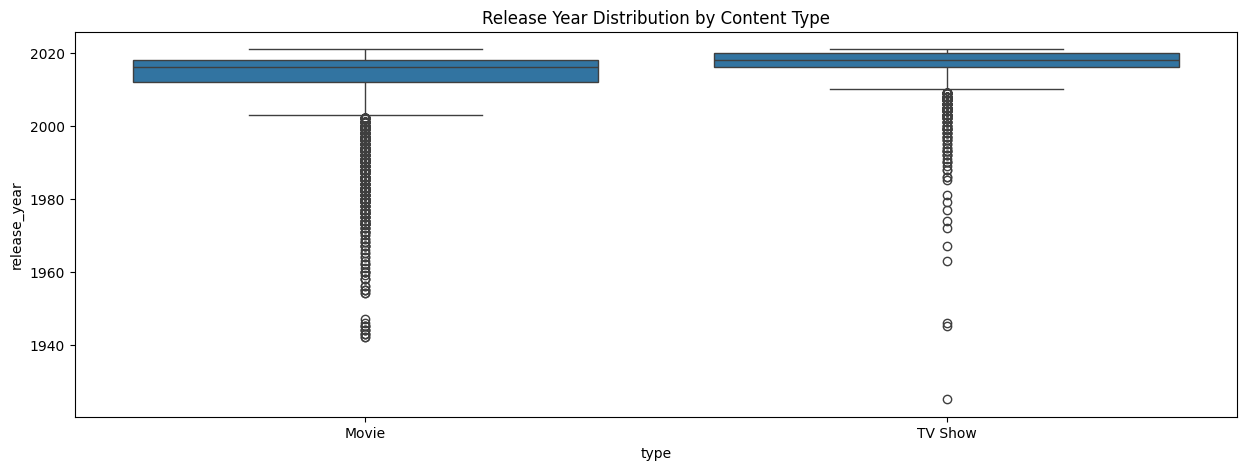

In [ ]:
plt.figure(figsize=(15,5))

sns.boxplot(
    x="type",
    y="release_year",
    data=data
)

plt.title("Release Year Distribution by Content Type")
plt.show()


**Outlier Check(From Boxplot):**

• In your boxplot we can clearly see, several dots below the lower whisker which are very old release years (1940s, 1950s, etc.), as most data concentrated after 2000.

• The boxplot reveals the presence of lower-end outliers for both Movies and TV Shows. These outliers correspond to older content released before 1980. However, these are valid historical entries and not data errors. Therefore, no outlier treatment was performed.

**Insights--What we observe from the box-plot:**  
•Median release year for both Movies and TV Shows is around 2005-2015.

•The boxplot indicates that most Netflix content was released after the year 2000.

•TV Shows appear more concentrated in recent years compared to Movies. Movies exhibit a wider spread in release years, including older titles. This suggests that Netflix maintains a mix of classic films while increasingly focusing on producing newer TV series.


**Recommendations:**

• Continue investing in original TV series, as recent trends show strong growth in this category.

• Maintain a balanced library of classic movies to attract nostalgic audiences.

• Focus more on producing new content rather than relying heavily on older titles.



## 5. Key Business Insights

1.Strong Shift Toward Recent Content:
Most content has been released and added after 2015, with a sharp increase in recent years.
This shows Netflix is aggressively expanding its content library.

2.TV Shows Are Growing Rapidly:
The trend analysis shows an increasing focus on TV shows compared to movies in recent years.
This indicates higher viewer engagement with episodic content.

3.Content Dominated by US and India:
The United States and India contribute a large portion of the content.
Emerging markets show strong regional content production.

4.Mature Content (TV-MA) Dominates:
Most content falls under TV-MA and TV-14 ratings.
This suggests Netflix primarily targets adult and young adult audiences.

5.Drama and International Genres Are Most Common:
Dramas and International TV shows are among the most frequent genres.
This reflects global audience demand for emotional and culturally diverse storytelling.

## 6. Business Recommendations

1.Increase Investment in High-Growth Regions:
Expand regional content production in India, UK, and other emerging markets to capture local audiences.

2.Focus More on High-Engagement TV Series:
Since TV shows are increasing and retain viewers longer, invest more in original series and multi-season storytelling.

3.Expand Family & Kids Content:
Since mature-rated content dominates, increasing PG and family content can help attract a wider demographic.

4.Strengthen International Genre Production:
Continue investing in international dramas and cross-border collaborations to maintain global appeal.

## 📌 Conclusion

This analysis highlights that Netflix's content library has experienced significant growth in recent years, with Movies dominating the platform and International Movies emerging as the most common genre. The United States and India contribute substantially to the catalog, while mature audience ratings such as TV-MA are the most prevalent.

These findings suggest opportunities for Netflix to continue expanding regional content, invest in high-performing genres, and increase the production of TV Shows in markets where Movies currently dominate. The insights from this analysis can support data-driven decisions for future content acquisition and production strategies.

---

## Thank You

Thank you for reviewing this project.

If you'd like to connect or discuss this analysis:

**GitHub:** <https://github.com/chethisowmya>

**LinkedIn:** <https://www.linkedin.com/in/sowmyachethi/>